# Example 1


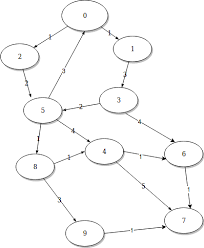

In [ ]:
# graph dictonary contains all the adjacent nodes of each as key and value pair
# cost_dict contains cost of each edge traversal of (u,v)
# final_dict contains all the possible paths from start node s to goal node g with total cost
from queue import PriorityQueue
from collections import defaultdict
import copy
import queue as Q

class Graph:
    def __init__(self):
        self.graph = dict()
        self.cost_dict=dict()
        self.final_dict=dict()

    # u and v are nodes: edge u-->v with cost c
    def addEdge(self,u,v,c):

        if u not in self.graph:
            qu = Q.PriorityQueue()
            self.graph.update({u:qu})

        self.graph[u].put(v)
        self.cost_dict.update({(u,v):c})

    # Makes a list to keep track of visited nodes
    def tnode(self,n):
        self.visited = [False]*n


    def UCS_util(self,s,visited,path,goal,value):
    # Appending node to the current path
        path.append(s)
    # Marking that node is visited
        visited[s]=True

    # If goal node is reached save the path and return
        if goal==s:
            self.final_dict.update({tuple(path):value})
            return

    # Checking if the adjacent node is been visited and explore the new path if haven't
        for i in self.graph[s].queue:
            if visited[i]==False:
                # When new path is being explored add the cost of that path to cost of entire course traversal
                # Send a copy of path list to avoid sending it by reference
                self.UCS_util(i,copy.deepcopy(visited),copy.deepcopy(path),goal,value + self.cost_dict[s,i])

    def UCS(self, s,goal):
        self.visited[s] = True
        # List to hold all the nodes visited in path from start node to goal node
        path=[s]

        for i in self.graph[s].queue:
            if self.visited[i] == False:
                # Make a variable to hold the cost of traversal
                value = self.cost_dict[s,i]
                self.UCS_util(i,copy.deepcopy(self.visited),copy.deepcopy(path),goal,value)

    # Display all the paths that is been discovered from start node to Goal node
    def all_paths(self):
      # Check if there is any path
        if bool(self.final_dict):
            print("All the paths: ")
            for i in self.final_dict:
                print ("path: ",i,"cost: ",self.final_dict[i])
        else:
            print( "No Path exist between start and goal node")

# Find the most optimal path between start node to goal node
    def optimal_path(self):
        if bool(self.final_dict):
            print ("best path: ",min(self.final_dict, key=self.final_dict.get))
        else:
            print ("No Path exist between start and goal node")
   # Creating Graph object and assigning number of nodes
g = Graph()
g.tnode(10)

#Making the Graph
g.addEdge(0, 1, 1); g.addEdge(0, 2, 1); g.addEdge(1, 3, 3);
g.addEdge(2, 5, 2); g.addEdge(3, 6, 4); g.addEdge(3, 5, 2);
g.addEdge(4, 6, 1); g.addEdge(4, 7, 5); g.addEdge(5, 4, 4);
g.addEdge(6, 7, 1); g.addEdge(5, 0, 3); g.addEdge(5, 8, 1);
g.addEdge(8, 4, 1); g.addEdge(8, 9, 3); g.addEdge(9, 7, 1);

#0 is start node and 7 is goal node
g.UCS(0,7)

#Find all the path between 0 and 7
g.all_paths()

#Find the most optimal path between 0 and 7
g.optimal_path()

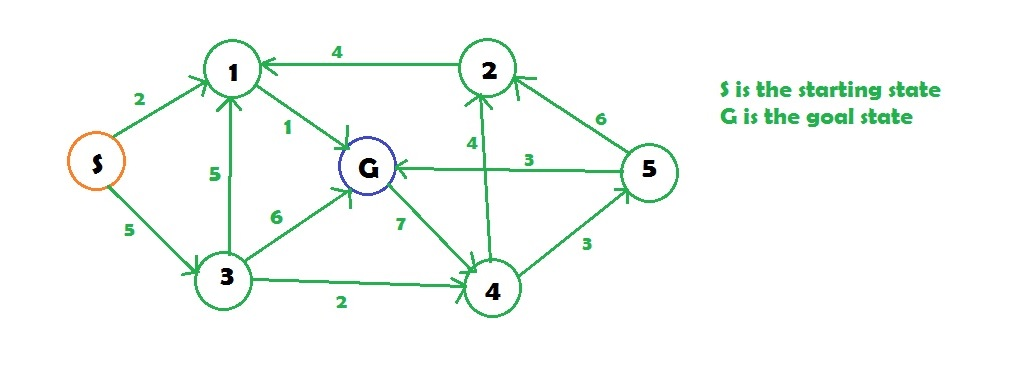

In [ ]:
# Python3 implementation of Uniform-Cost Search

# returns the minimum cost in a vector( if
# there are multiple goal states)
def  uniform_cost_search(goal, start):

    # minimum cost upto
    # goal state from starting
    global graph,cost
    answer = []

    # create a priority queue
    queue = []

    # set the answer vector to max value
    for i in range(len(goal)):
        answer.append(10**8)

    # insert the starting index
    queue.append([0, start])

    # map to store visited node
    visited = {}

    # count
    count = 0x

    # while the queue is not empty
    while (len(queue) > 0):

        # get the top element of the
        queue = sorted(queue)
        p = queue[-1]

        # pop the element
        del queue[-1]

        # get the original value
        p[0] *= -1

        # check if the element is part of
        # the goal list
        if (p[1] in goal):

            # get the position
            index = goal.index(p[1])

            # if a new goal is reached
            if (answer[index] == 10**8):
                count += 1

            # if the cost is less
            if (answer[index] > p[0]):
                answer[index] = p[0]

            # pop the element
            del queue[-1]

            queue = sorted(queue)
            if (count == len(goal)):
                return answer

        # check for the non visited nodes
        # which are adjacent to present node
        if (p[1] not in visited):
            for i in range(len(graph[p[1]])):

                # value is multiplied by -1 so that
                # least priority is at the top
                queue.append( [(p[0] + cost[(p[1], graph[p[1]][i])])* -1, graph[p[1]][i]])

        # mark as visited
        visited[p[1]] = 1

    return answer

# main function
if __name__ == '__main__':

    # create the graph
    graph,cost = [[] for i in range(8)],{}

    # add edge
    graph[0].append(1)
    graph[0].append(3)
    graph[3].append(1)
    graph[3].append(6)
    graph[3].append(4)
    graph[1].append(6)
    graph[4].append(2)
    graph[4].append(5)
    graph[2].append(1)
    graph[5].append(2)
    graph[5].append(6)
    graph[6].append(4)

    # add the cost
    cost[(0, 1)] = 2
    cost[(0, 3)] = 5
    cost[(1, 6)] = 1
    cost[(3, 1)] = 5
    cost[(3, 6)] = 6
    cost[(3, 4)] = 2
    cost[(2, 1)] = 4
    cost[(4, 2)] = 4
    cost[(4, 5)] = 3
    cost[(5, 2)] = 6
    cost[(5, 6)] = 3
    cost[(6, 4)] = 7

    # goal state
    goal = []

    # set the goal
    # there can be multiple goal states
    goal.append(6)

    # get the answer
    answer = uniform_cost_search(goal, 0)

    # print the answer
    print("Minimum cost from 0 to 6 is = ",answer[0])